<a href="https://colab.research.google.com/github/niclohan/CalculoNumerico/blob/main/Atividade2_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Resolução dos 7 itens da Atividade Prática II**

**Nome e RA:**

Livia Kaori Shiba - 185281

Nichollas Lohan - 164928

Foi utilizada a função `simular` fornecida no enunciado, preservando a atualização da
equação diferencial, a ordem das operações e a detecção de falhas. As células
adicionadas realizam os testes e apresentam os cálculos, as tabelas, os gráficos
e as respostas solicitadas.

Bibliotecas:


In [60]:
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

Definindo os parametros globais:

In [61]:
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
})
pd.set_option("display.max_columns", None)

H = 0.01       # m
nu = 1e-4      # m²/s
U = 1.0        # m/s
pontos = 21
passos = 2000

print("Parametros globais:")
print(f"H = {H} m")
print(f"ν = {nu} m²/s")
print(f"U = {U} m/s")
print(f"Pontos = {pontos}")
print(f"Passos = {passos}")

Parametros globais:
H = 0.01 m
ν = 0.0001 m²/s
U = 1.0 m/s
Pontos = 21
Passos = 2000


## 1. Verificação da estabilidade

Os 21 pontos incluem as duas paredes; portanto, existem 20 intervalos espaciais:

$$\Delta y=\frac{H}{21-1}=\frac{0{,}01}{20}
=0{,}0005\ \mathrm{m}.$$

Para o esquema explícito fornecido, a condição de estabilidade é
$r=\nu\Delta t/\Delta y^2\leq 1/2$. Assim,

$$\Delta t_{\max}=\frac{\Delta y^2}{2\nu}
=\frac{(0{,}0005)^2}{2\cdot 10^{-4}}
=0{,}00125\ \mathrm{s}.$$

**Caso A:** $\Delta t=0{,}001\ \mathrm{s}$ e
$r_A=10^{-4}(0{,}001)/(0{,}0005)^2=0{,}4$.
Como $0{,}4\leq 0{,}5$, o caso é **estável**.

**Caso B:** $\Delta t=0{,}002\ \mathrm{s}$ e
$r_B=10^{-4}(0{,}002)/(0{,}0005)^2=0{,}8$.
Como $0{,}8>0{,}5$, o caso é **instável**.

Essa classificação é feita antes de executar a simulação.

In [62]:
dy = H / (pontos - 1)
dt_max = dy**2 / (2 * nu)
print(f"Δy = {dy:.7f} m")
print(f"Δt máximo = {dt_max:.7f} s")

linhas = []
for caso, dt in (("A", 0.001), ("B", 0.002)):
    r = nu * dt / dy**2
    linhas.append({
        "Caso": caso,
        "Δt (s)": dt,
        "r": round(r, 6),
        "Classificação": "Estável" if r <= 0.5 else "Instável",
    })
display(pd.DataFrame(linhas).set_index("Caso"))

Δy = 0.0005000 m
Δt máximo = 0.0012500 s


,Δt (s),r,Classificação
Caso,,,
A,0.001,0.4,Estável
B,0.002,0.8,Instável


## 2. Detecção de overflow

A função abaixo é a implementação do PDF. `np.errstate(over="raise",
invalid="raise")` transforma overflow e operações inválidas em exceções
`FloatingPointError`, que são capturadas para interromper a simulação.

São executadas as quatro combinações de tipo numérico e passo de tempo, com
21 pontos e até 2.000 passos. O campo `falha` indica a **iteração tentada que
falhou**, contada a partir de 1. O vetor `u` e o histórico retornados contêm
somente os estados calculados antes dessa falha.

In [63]:
def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )
            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break
            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }

In [64]:
resultados = {}
linhas = []
for tipo in (np.float32, np.float64):
    for caso, dt in (("A", 0.001), ("B", 0.002)):
        resultado = simular(dt, tipo, passos=passos, pontos=pontos)
        resultados[(tipo.__name__, caso)] = resultado
        falha = resultado["falha"]
        linhas.append({
            "Tipo numérico": tipo.__name__,
            "Caso": caso,
            "Δt (s)": dt,
            "r (aprox.)": round(resultado["r"], 6),
            "Overflow": "Sim" if falha is not None else "Não",
            "Iteração da falha": str(falha) if falha is not None else "—",
            "Tempo da falha (s)": f"{falha * dt:.3f}" if falha is not None else "—",
            "Passos concluídos": len(resultado["tempos"]) - 1,
        })

tabela_testes = pd.DataFrame(linhas).set_index(["Tipo numérico", "Caso"])
display(tabela_testes)

dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


Δt (s)  r (aprox.) Overflow Iteração da falha  \
Tipo numérico Caso                                                  
float32       A      0.001         0.4      Não                 —   
              B      0.002         0.8      Sim               121   
float64       A      0.001         0.4      Não                 —   
              B      0.002         0.8      Sim               917   

                   Tempo da falha (s)  Passos concluídos  
Tipo numérico Caso                                        
float32       A                     —               2000  
              B                 0.242                120  
float64       A                     —               2000  
              B                 1.834                916

In [65]:
b32 = resultados[("float32", "B")]
b64 = resultados[("float64", "B")]
display(Markdown(
    f"**Resposta:** o caso A completou os {passos:,} passos nos dois tipos, "
    "atingindo **2 s sem overflow**. No caso B, houve overflow no passo "
    f"**{b32['falha']}** com `float32` e no passo **{b64['falha']}** com `float64`. "
    "As mensagens acima confirmam que as falhas observadas foram de overflow. "
    "O valor de `r` foi arredondado apenas na tabela; a função mantém o valor "
    "representável no tipo escolhido."
))

**Resposta:** o caso A completou os 2,000 passos nos dois tipos, atingindo **2 s sem overflow**. No caso B, houve overflow no passo **121** com `float32` e no passo **917** com `float64`. As mensagens acima confirmam que as falhas observadas foram de overflow. O valor de `r` foi arredondado apenas na tabela; a função mantém o valor representável no tipo escolhido.

## 3. Interpretação física

O gráfico mostra $\max_i |u_i|$ ao longo do tempo. O eixo vertical usa escala
logarítmica para permitir a comparação de valores separados por muitas ordens
de grandeza. As curvas estáveis se sobrepõem em $1\ \mathrm{m/s}$, pois a
parede móvel permanece nesse valor desde o início.

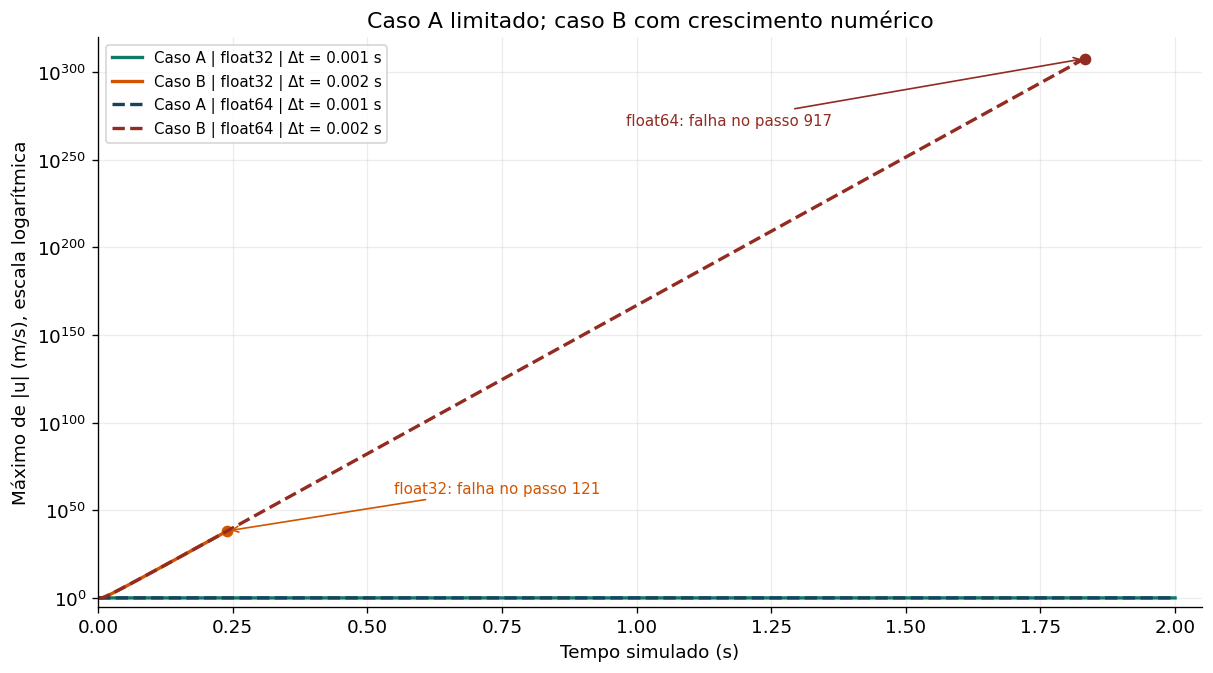

In [66]:
fig, ax = plt.subplots(figsize=(10, 5.5), layout="constrained")
cores = {("float32", "A"): "#117A65", ("float64", "A"): "#154360",
         ("float32", "B"): "#D35400", ("float64", "B"): "#922B21"}
# Calcula o log10 para evitar overflow no ajuste dos eixos do Matplotlib.
# Os rótulos do eixo continuam mostrando os valores de velocidade em m/s.
for (tipo, caso), resultado in resultados.items():
    dt = 0.001 if caso == "A" else 0.002
    ax.plot(
        resultado["tempos"], np.log10(resultado["maximos"]),
        label=f"Caso {caso} | {tipo} | Δt = {dt} s",
        color=cores[(tipo, caso)],
        linestyle="--" if tipo == "float64" else "-",
        linewidth=2,
    )
    if resultado["falha"] is not None:
        ax.plot(resultado["tempos"][-1], np.log10(resultado["maximos"][-1]),
                "o", color=cores[(tipo, caso)], markersize=6)

ax.set_ylim(-5, 320)
expoentes = np.arange(0, 301, 50)
ax.set_yticks(expoentes, [rf"$10^{{{e}}}$" for e in expoentes])
ax.set_xlim(0, 2.05)
ax.set_xlabel("Tempo simulado (s)")
ax.set_ylabel("Máximo de |u| (m/s), escala logarítmica")
ax.set_title("Caso A limitado; caso B com crescimento numérico")
ax.legend(loc="upper left", fontsize=9)
ax.annotate(
    f"float32: falha no passo {b32['falha']}",
    xy=(b32["tempos"][-1], np.log10(b32["maximos"][-1])),
    xytext=(0.55, 60), color=cores[("float32", "B")], fontsize=9,
    arrowprops={"arrowstyle": "->", "color": cores[("float32", "B")]},
)
ax.annotate(
    f"float64: falha no passo {b64['falha']}",
    xy=(b64["tempos"][-1], np.log10(b64["maximos"][-1])),
    xytext=(0.98, 270), color=cores[("float64", "B")], fontsize=9,
    arrowprops={"arrowstyle": "->", "color": cores[("float64", "B")]},
)
plt.show()

**Resposta:** a viscosidade transmite o movimento da parede para o interior do
fluido e suaviza as diferenças de velocidade. Com as condições do problema,
a solução física deve obedecer a $0\leq u(y,t)\leq 1\ \mathrm{m/s}$. Ela se
aproxima de um perfil linear limitado, sem crescimento ilimitado.

No caso A, $r=0{,}4$ e a atualização tem pesos $0{,}4$, $0{,}2$ e $0{,}4$:
é uma média ponderada dos valores anteriores. No caso B, $r=0{,}8$ e o peso
central é $1-2r=-0{,}6$, favorecendo oscilações crescentes e velocidades não
físicas. O crescimento observado decorre da discretização instável.

O máximo constante do caso A **não significa que todo o fluido já esteja em
regime estacionário**: a parede móvel, incluída no cálculo do máximo, vale
$1\ \mathrm{m/s}$ enquanto o interior ainda evolui. Os pontos marcados no
gráfico são os últimos estados finitos salvos, anteriores à iteração da falha.

In [67]:
primeiro_excesso = next(
    i for i, valor in enumerate(b64["maximos"]) if valor > U
)
display(Markdown(
    f"No caso B com `float64`, o máximo já ultrapassa o limite físico no "
    f"**passo {primeiro_excesso}**, em "
    f"**{b64['tempos'][primeiro_excesso]:.3f} s**, quando chega a "
    f"**{b64['maximos'][primeiro_excesso]:.2f} m/s**. "
    f"O overflow só é detectado no passo {b64['falha']}. "
    "Portanto, a solução já está incorreta muito antes do overflow."
))

No caso B com `float64`, o máximo já ultrapassa o limite físico no **passo 3**, em **0.006 s**, quando chega a **1.12 m/s**. O overflow só é detectado no passo 917. Portanto, a solução já está incorreta muito antes do overflow.

## 4. Capacidade de representação

Overflow ocorre quando o resultado de uma operação ultrapassa a faixa finita
representável pelo tipo numérico. A tabela compara essa faixa e a precisão
dos dois tipos; `eps` é a distância entre 1 e o próximo número representável
acima de 1.

In [68]:
display(pd.DataFrame([
    {
        "Tipo numérico": tipo.__name__,
        "Maior valor finito": f"{np.finfo(tipo).max:.6e}",
        "eps": f"{np.finfo(tipo).eps:.6e}",
        "Falha no caso B": resultados[(tipo.__name__, "B")]["falha"],
    }
    for tipo in (np.float32, np.float64)
]).set_index("Tipo numérico"))

,Maior valor finito,eps,Falha no caso B
Tipo numérico,,,
float32,3.402823e+38,1.192093e-07,121
float64,1.797693e+308,2.220446e-16,917


**Resposta:** mudar de `float32` para `float64` **não elimina a instabilidade**.
O valor de $r$ continua aproximadamente $0{,}8$, acima do limite. O tipo
numérico não corrige a escolha do passo de tempo.

O `float32` suporta valores finitos de até aproximadamente $3{,}4\times10^{38}$,
enquanto o `float64` chega a cerca de $1{,}8\times10^{308}$. Por isso, no caso B,
o crescimento numérico ultrapassa a capacidade do `float32` antes da do
`float64`. A maior precisão do `float64` também reduz erros de arredondamento,
mas a faixa de expoentes muito maior explica o adiamento do overflow.

Assim, **instabilidade** é o crescimento de perturbações e erros pelo esquema
numérico; **overflow** é a ultrapassagem da faixa de representação em uma
operação. Essa operação pode ser intermediária, como `2*u` ou a soma dos
termos. Não é necessário que o último valor de velocidade armazenado já
tenha alcançado o maior número finito. As iterações registradas correspondem
a esta implementação e execução; a ordem das operações pode afetar quando
a falha aparece.

## 5. Refinamento da malha

Com 41 pontos, há 40 intervalos:

$$\Delta y_{41}=\frac{0{,}01}{40}=0{,}00025\ \mathrm{m},$$

$$\Delta t_{\max,41}=\frac{(0{,}00025)^2}{2\cdot10^{-4}}
=0{,}0003125\ \mathrm{s}.$$

Mantendo $\Delta t=0{,}001\ \mathrm{s}$:

$$r=\frac{10^{-4}\cdot0{,}001}{(0{,}00025)^2}=1{,}6>0{,}5,$$

portanto a simulação fica **instável**, embora esse passo fosse estável com
21 pontos. Para corrigir, escolhe-se $\Delta t=0{,}00025\ \mathrm{s}$, abaixo
do novo limite. Nesse caso, $r=0{,}4$ e a execução é **estável**.

Os dois testes são repetidos para ambos os tipos numéricos, com até 2.000 passos.

In [69]:
pontos_ref = 41
dy_ref = H / (pontos_ref - 1)
dt_max_ref = dy_ref**2 / (2 * nu)
dt_ref = 0.00025
print(f"Novo Δy = {dy_ref:.8f} m")
print(f"Novo Δt máximo = {dt_max_ref:.8f} s")

refinados = {}
linhas = []
for tipo in (np.float32, np.float64):
    for dt in (0.001, dt_ref):
        resultado = simular(dt, tipo, passos=passos, pontos=pontos_ref)
        refinados[(tipo.__name__, dt)] = resultado
        falha = resultado["falha"]
        linhas.append({
            "Tipo numérico": tipo.__name__,
            "Δt (s)": dt,
            "r (aprox.)": round(resultado["r"], 6),
            "Classificação": "Estável" if resultado["r"] <= 0.5 else "Instável",
            "Overflow": "Sim" if falha is not None else "Não",
            "Iteração da falha": str(falha) if falha is not None else "—",
            "Tempo da falha (s)": f"{falha * dt:.3f}" if falha is not None else "—",
            "Último tempo salvo (s)": resultado["tempos"][-1],
        })

tabela_refinamento = pd.DataFrame(linhas).set_index(["Tipo numérico", "Δt (s)"])
display(tabela_refinamento)

Novo Δy = 0.00025000 m
Novo Δt máximo = 0.00031250 s
dt=0.001, float32: falha no passo 56, t=0.0560 s - overflow encountered in multiply
dt=0.00025, float32: 2000 passos sem overflow.
dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract
dt=0.00025, float64: 2000 passos sem overflow.


r (aprox.) Classificação Overflow Iteração da falha  \
Tipo numérico Δt (s)                                                         
float32       0.00100         1.6      Instável      Sim                56   
              0.00025         0.4       Estável      Não                 —   
float64       0.00100         1.6      Instável      Sim               426   
              0.00025         0.4       Estável      Não                 —   

                      Tempo da falha (s)  Último tempo salvo (s)  
Tipo numérico Δt (s)                                              
float32       0.00100              0.056                   0.055  
              0.00025                  —                   0.500  
float64       0.00100              0.426                   0.425  
              0.00025                  —                   0.500

In [70]:
ref32 = refinados[("float32", 0.001)]
ref64 = refinados[("float64", 0.001)]
display(Markdown(
    f"**Resposta:** com 41 pontos e Δt = 0,001 s, ocorreu overflow nos passos "
    f"**{ref32['falha']}** (`float32`) e **{ref64['falha']}** (`float64`). "
    "Ao reduzir o espaçamento à metade e manter Δt, o valor de r quadruplicou, "
    "passando de 0,4 para 1,6. Ao reduzir também Δt por um fator 4, para "
    "**0,00025 s**, r voltou a 0,4 e os dois tipos completaram 2.000 passos "
    "sem overflow. Esse teste estável simula **0,5 s**; a estabilidade, por si só, "
    "não garante que o regime estacionário já tenha sido alcançado."
))

**Resposta:** com 41 pontos e Δt = 0,001 s, ocorreu overflow nos passos **56** (`float32`) e **426** (`float64`). Ao reduzir o espaçamento à metade e manter Δt, o valor de r quadruplicou, passando de 0,4 para 1,6. Ao reduzir também Δt por um fator 4, para **0,00025 s**, r voltou a 0,4 e os dois tipos completaram 2.000 passos sem overflow. Esse teste estável simula **0,5 s**; a estabilidade, por si só, não garante que o regime estacionário já tenha sido alcançado.

## 6. Verificação do perfil de velocidade

A solução estacionária de referência é

$$u_{\mathrm{est}}(y)=U\left(1-\frac{y}{H}\right),$$

e a diferença máxima é

$$E_\infty=\max_i|u_i-u_{\mathrm{est}}(y_i)|.$$

São reaproveitadas as execuções estáveis com 21 pontos, que chegaram a
$t=2\ \mathrm{s}$. Para verificar o efeito de um transiente ainda presente,
compara-se também o caso estável de 41 pontos em $t=0{,}5\ \mathrm{s}$ com uma
execução mais longa, de **8.000 passos**, que chega aos mesmos $2\ \mathrm{s}$.
Usa-se `float64` nessa comparação temporal para reduzir a influência do
arredondamento.

In [71]:
ref_longo = simular(dt_ref, np.float64, passos=8000, pontos=pontos_ref)
perfis = {
    "21 pontos, float32, 2 s": resultados[("float32", "A")],
    "21 pontos, float64, 2 s": resultados[("float64", "A")],
    "41 pontos, float64, 0,5 s": refinados[("float64", dt_ref)],
    "41 pontos, float64, 2 s": ref_longo,
}

erros = {}
linhas = []
for nome, resultado in perfis.items():
    u_est = U * (1 - resultado["y"] / H)
    # Compara em float64 para não arredondar a referência a float32.
    erro = np.max(np.abs(resultado["u"].astype(np.float64) - u_est))
    erros[nome] = float(erro)
    linhas.append({
        "Execução": nome,
        "Tempo final (s)": resultado["tempos"][-1],
        "E∞ (m/s)": float(erro),
    })

tabela_perfis = pd.DataFrame(linhas).set_index("Execução")
display(tabela_perfis.assign(**{
    "E∞ (m/s)": tabela_perfis["E∞ (m/s)"].map("{:.6e}".format)
}))

dt=0.00025, float64: 8000 passos sem overflow.


,Tempo final (s),E∞ (m/s)
Execução,,
"21 pontos, float32, 2 s",2.0,2.074242e-06
"21 pontos, float64, 2 s",2.0,1.605312e-09
"41 pontos, float64, 0,5 s",0.5,4.559899e-03
"41 pontos, float64, 2 s",2.0,1.678226e-09


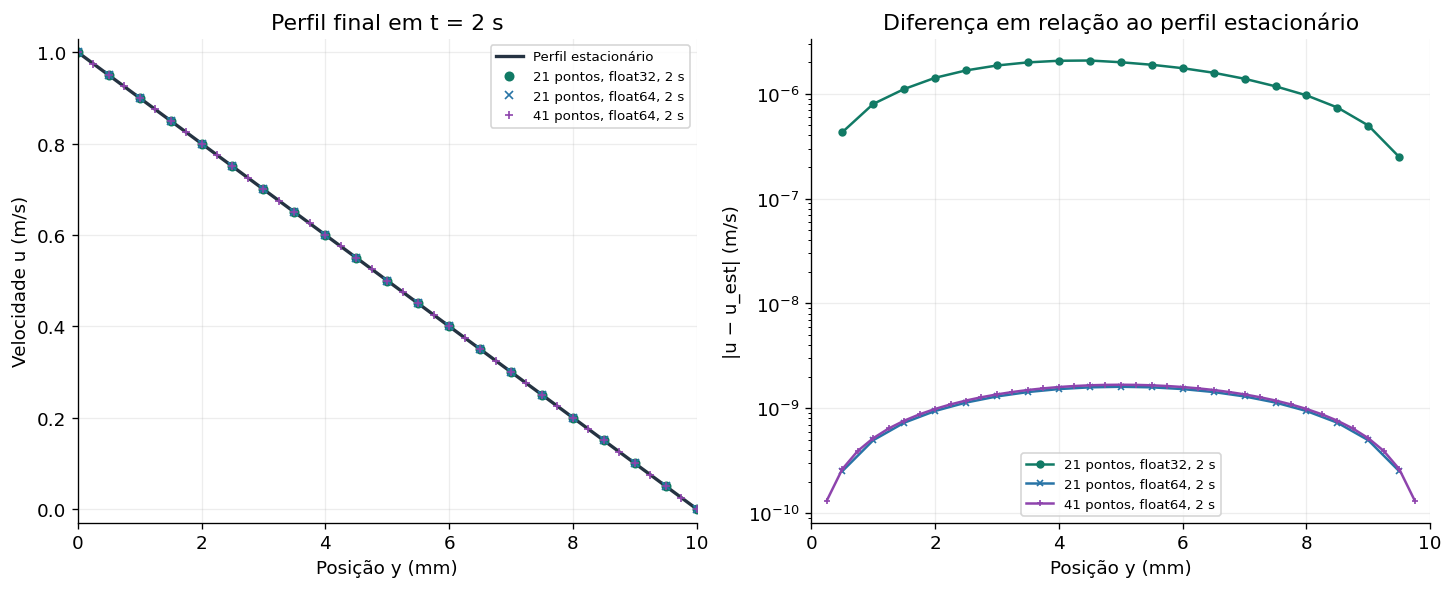

In [72]:
fig, (ax_perfil, ax_erro) = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")
y_est = np.linspace(0, H, 201)
ax_perfil.plot(1000 * y_est, U * (1 - y_est / H), color="#253342",
               linewidth=2, label="Perfil estacionário")

estilos = [
    ("21 pontos, float32, 2 s", "#117A65", "o"),
    ("21 pontos, float64, 2 s", "#2874A6", "x"),
    ("41 pontos, float64, 2 s", "#8E44AD", "+"),
]
for nome, cor, marcador in estilos:
    resultado = perfis[nome]
    y_mm = 1000 * resultado["y"]
    u_est = U * (1 - resultado["y"] / H)
    ax_perfil.plot(y_mm, resultado["u"], linestyle="none", marker=marcador,
                   markersize=5, color=cor, label=nome)
    erro_pontual = np.abs(resultado["u"].astype(np.float64) - u_est)
    # Exclui somente zeros do gráfico logarítmico; E∞ usa todos os pontos.
    positivo = erro_pontual > 0
    ax_erro.semilogy(y_mm[positivo], erro_pontual[positivo], marker=marcador,
                     markersize=4, color=cor, label=nome)

ax_perfil.set(xlabel="Posição y (mm)", ylabel="Velocidade u (m/s)",
              title="Perfil final em t = 2 s", xlim=(0, 10), ylim=(-0.03, 1.03))
ax_erro.set(xlabel="Posição y (mm)", ylabel="|u − u_est| (m/s)",
            title="Diferença em relação ao perfil estacionário", xlim=(0, 10))
ax_perfil.legend(fontsize=8, loc="upper right")
ax_erro.legend(fontsize=8, loc="lower center")
plt.show()

In [73]:
e21_32 = erros["21 pontos, float32, 2 s"]
e21_64 = erros["21 pontos, float64, 2 s"]
e41_curto = erros["41 pontos, float64, 0,5 s"]
e41_longo = erros["41 pontos, float64, 2 s"]
display(Markdown(
    "**Resposta:** em 2 s, os perfis finais praticamente coincidem com a reta "
    "estacionária. Para 21 pontos, obteve-se "
    f"**E∞ ≈ {e21_32:.3e} m/s** em `float32` e "
    f"**E∞ ≈ {e21_64:.3e} m/s** em `float64`. "
    "No teste de 41 pontos em `float64`, aumentar o tempo de 0,5 s para 2 s "
    f"reduziu E∞ de **{e41_curto:.3e} m/s** para **{e41_longo:.3e} m/s**. "
    "Adotando como referência uma diferença máxima menor que **10⁻⁵ m/s**, "
    "os três testes em 2 s aproximam suficientemente o regime estacionário; "
    "o teste de 0,5 s ainda não atende a esse critério."
))

**Resposta:** em 2 s, os perfis finais praticamente coincidem com a reta estacionária. Para 21 pontos, obteve-se **E∞ ≈ 2.074e-06 m/s** em `float32` e **E∞ ≈ 1.605e-09 m/s** em `float64`. No teste de 41 pontos em `float64`, aumentar o tempo de 0,5 s para 2 s reduziu E∞ de **4.560e-03 m/s** para **1.678e-09 m/s**. Adotando como referência uma diferença máxima menor que **10⁻⁵ m/s**, os três testes em 2 s aproximam suficientemente o regime estacionário; o teste de 0,5 s ainda não atende a esse critério.

O erro maior em `float32` é compatível com sua menor precisão e com o acúmulo
de arredondamento; prolongar uma execução não remove automaticamente essa
limitação. Já a redução expressiva de $E_\infty$ entre $0{,}5$ e $2$ s,
mantendo a mesma malha, o mesmo passo e `float64`, evidencia o decaimento do
transiente.

O perfil linear é estacionário também para a diferença central utilizada,
pois sua segunda diferença é nula, em aritmética exata. Por isso, $E_\infty$
em relação a essa reta pode conter o transiente ainda não concluído e efeitos
de arredondamento. **Não é, isoladamente, o erro do método em relação à
solução transiente exata.** O perfil estacionário não descreve a condição
inicial nem toda a evolução temporal.

## 7. Conclusão

O refinamento da malha reduz $\Delta y$, mas torna mais restritivo o passo de
tempo admissível no esquema explícito, pois
$\Delta t_{\max}=\Delta y^2/(2\nu)$. Ao reduzir $\Delta y$ à metade,
é necessário reduzir $\Delta t$ por um fator 4 para manter o mesmo $r$.

Nos testes com $r=0{,}4$, a solução permaneceu limitada e aproximou o perfil
estacionário quando o tempo simulado foi suficiente. Nos casos com $r=0{,}8$
e $r=1{,}6$, o esquema amplificou oscilações, produziu valores não físicos e
posteriormente apresentou overflow. A instabilidade apareceu antes da
ultrapassagem da capacidade do tipo numérico.

**A alteração que corrigiu a causa da falha foi reduzir o passo de tempo para
respeitar a condição de estabilidade:** de $0{,}002$ para $0{,}001\ \mathrm{s}$
com 21 pontos e de $0{,}001$ para $0{,}00025\ \mathrm{s}$ com 41 pontos. Trocar
`float32` por `float64` apenas adiou o overflow nos casos instáveis; não
substituiu a correção de $\Delta t$.

In [74]:
# Verificação final dos resultados essenciais da atividade.
assert np.isclose(dy, 0.0005) and np.isclose(dt_max, 0.00125)
assert np.isclose(dy_ref, 0.00025) and np.isclose(dt_max_ref, 0.0003125)
for tipo in ("float32", "float64"):
    assert resultados[(tipo, "A")]["falha"] is None
    assert resultados[(tipo, "B")]["falha"] is not None
    assert refinados[(tipo, 0.001)]["falha"] is not None
    assert refinados[(tipo, dt_ref)]["falha"] is None
for resultado in perfis.values():
    assert resultado["falha"] is None
    assert np.all(np.isfinite(resultado["u"]))
    assert resultado["u"][0] == U and resultado["u"][-1] == 0
    assert np.all((resultado["u"] >= 0) & (resultado["u"] <= U))
assert e21_32 < 1e-5 and e21_64 < 1e-5 and e41_longo < 1e-5
assert e41_longo < e41_curto
print("Verificações concluídas: estabilidade, falhas, paredes e perfis coerentes.")

Verificações concluídas: estabilidade, falhas, paredes e perfis coerentes.
